In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)



from data_generation.differential_equations import ElasticityLeastSquares
from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, evaluate_expression
from utils import plot_real_valued_function, plot_block_sparsity, plot_block_submatrix_sparsity

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem
from tqdm import tqdm

----------------------------------------
2026-03-02 20:59:08 - Start Program
----------------------------------------


In [2]:
import matplotlib as mpl

mpl.rcParams['axes.titlesize'] = 32             # Title font size
mpl.rcParams['axes.labelsize'] = 16             # Axis label font size
mpl.rcParams['xtick.labelsize'] = 26            # X tick font size
mpl.rcParams['ytick.labelsize'] = 26            # Y tick font size
mpl.rcParams['figure.titlesize'] = 22           # Figure title size
mpl.rcParams['legend.fontsize'] = 16            # Legend size
mpl.rcParams['font.size'] = 16                  # Base default font size

In [3]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"
model_train_outputs_path = repo_path + "/results/elasticity/model_train_outputs/rbno_physics_loss"
model_test_outputs_path = repo_path + "/results/elasticity/model_test_outputs/rbno_physics_loss"

mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)

In [4]:
num_test = 500

test_p_dof = load_npy(test_dataset_path+'/p_dof.npy')[:num_test]
test_sigma_u_dof = load_npy(test_dataset_path+'/sigma_u_dof.npy')[:num_test]
test_p_vertex_values = load_npy(test_dataset_path+'/p_vertex_values.npy')[:num_test]

In [5]:
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

In [6]:
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
num_vertices = len(dolfinx_mesh_coords)
x = np.linspace(0, mesh_args['upper_right_x'], mesh_args['num_x']+1)
y = np.linspace(0, mesh_args['upper_right_y'], mesh_args['num_y']+1)
image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

In [7]:
test_p_vertex_values = np.zeros((num_test, num_vertices))
for i in range(num_test):
    p = dolfinx.fem.Function(Vh['CG1'])
    p.x.array[:] = test_p_dof[i]
    test_p_vertex_values[i][perm] = p.x.array[:][scifem.vertex_to_dofmap(Vh['CG1'])]

test_image_p_vertex_values = np.zeros((num_test, 1, mesh_args['num_y']+1, mesh_args['num_x']+1))
for i in range(num_test):
    test_image_p_vertex_values[i,0,:,:] = test_p_vertex_values[i].reshape(mesh_args['num_x']+1, mesh_args['num_y']+1).T

In [8]:
for i in range(3):
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    img = plt.imshow(test_image_p_vertex_values[i,0,:,:],
                     extent=[0, 2, 0, 1], origin='lower', cmap='turbo')

    cbar = plt.colorbar(fraction=0.025, pad=0.001)
    cbar.ax.tick_params()  # Increase colorbar tick labels

    plt.title(r'Parameter $\mathfrak{p}$', pad=12)
    plt.xticks()
    plt.yticks()
    ax.set_aspect(1.0, adjustable="box")


    plt.savefig(os.path.join(model_test_outputs_path, f'test_p_{i}.png'),
                dpi=300, bbox_inches='tight')
    plt.close()

In [9]:
def plot_reference_scalar_function(x, y, grid_evals, variable_name,
                        levels=100,
                        fmt="%.2f"):
    
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

    cf = ax.tricontourf(x, y, grid_evals, levels=levels, cmap="turbo")
    ax.set_title(f"Reference solution {variable_name}", pad=12)
    ax.tick_params(axis="both", which="major")
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])
    plt.xticks()
    plt.yticks()
    ax.set_aspect(1.0, adjustable="box")

    cbar = fig.colorbar(cf, ax=ax, format=fmt, pad=0.001, fraction=0.025)
    cbar.ax.tick_params()
    cbar.locator = ticker.MaxNLocator(nbins=5)
    cbar.update_ticks()

    ax.tick_params(left=False, bottom=False)
    return fig

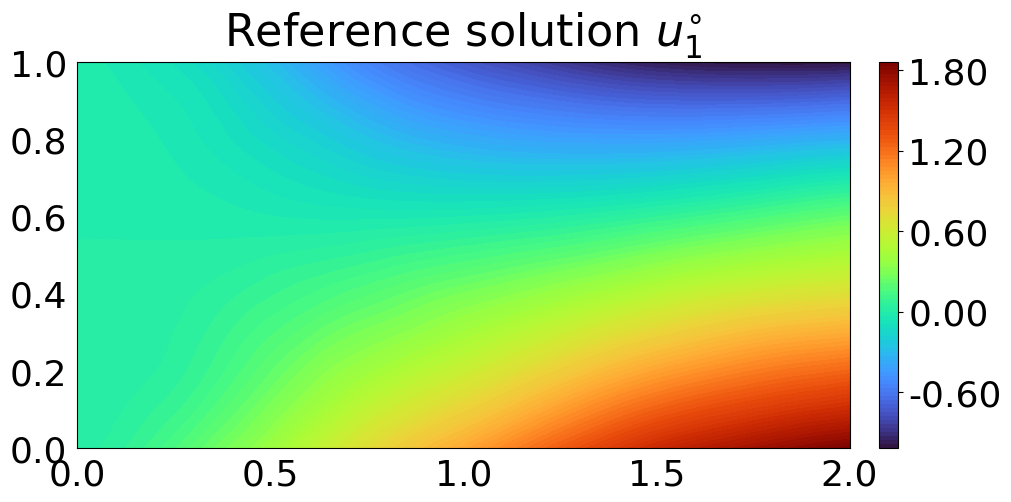

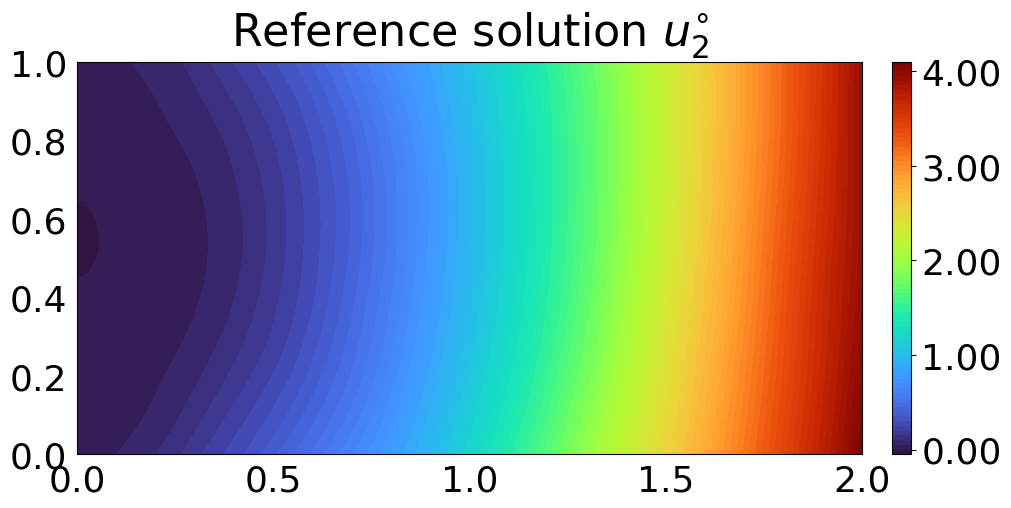

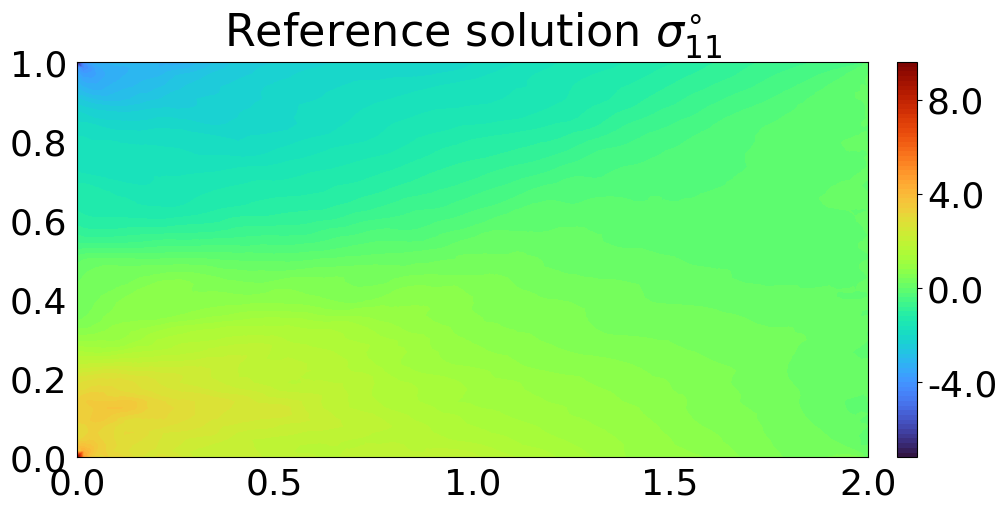

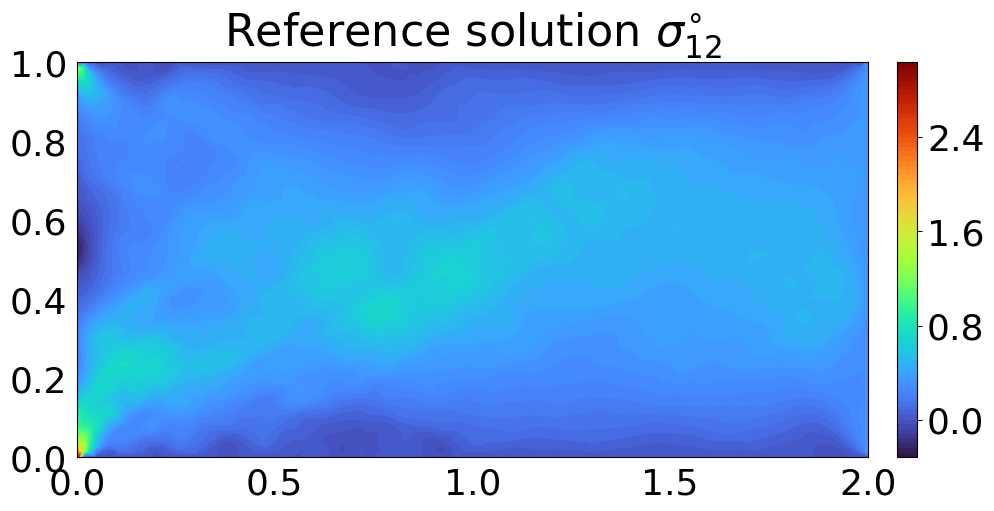

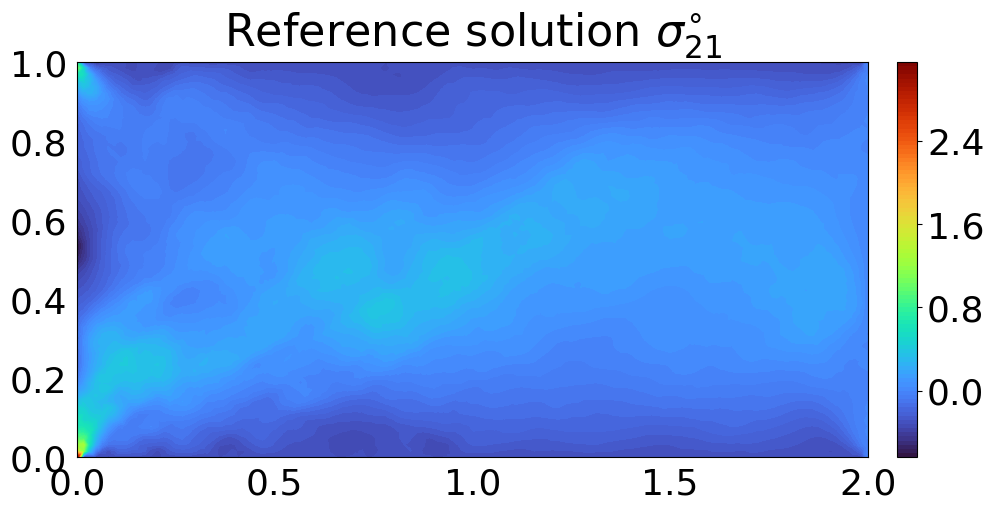

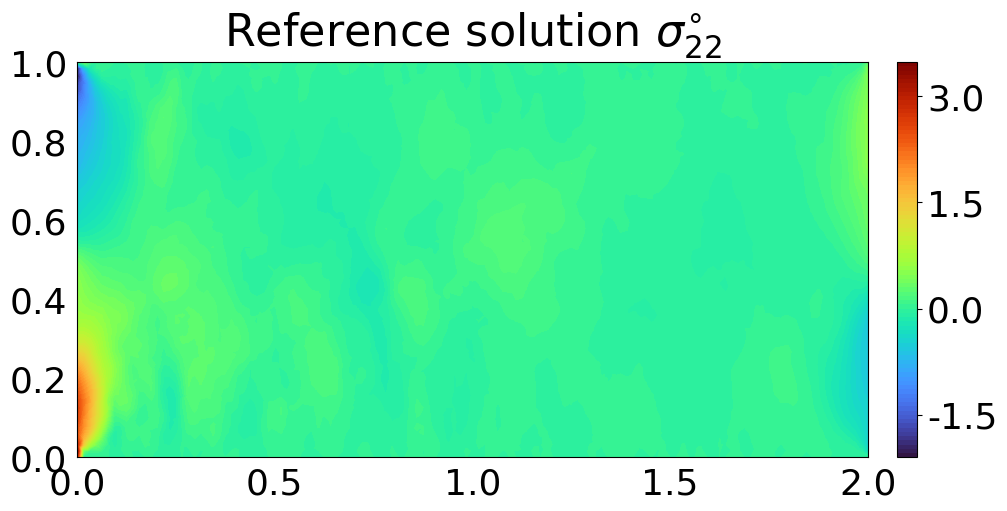

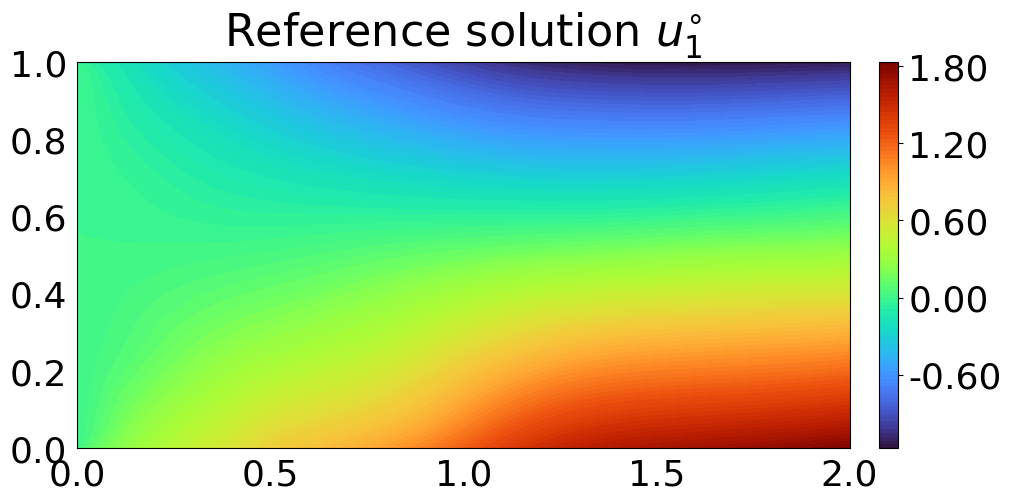

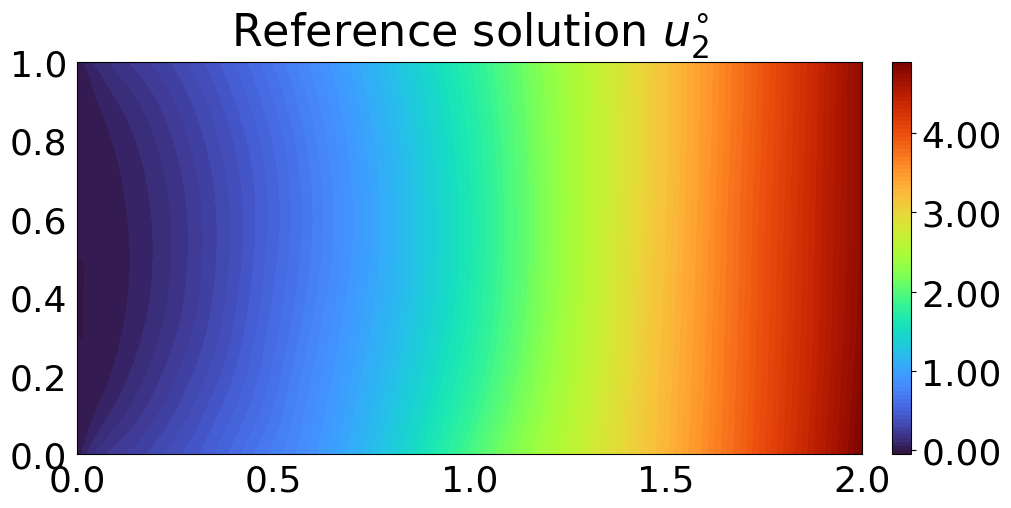

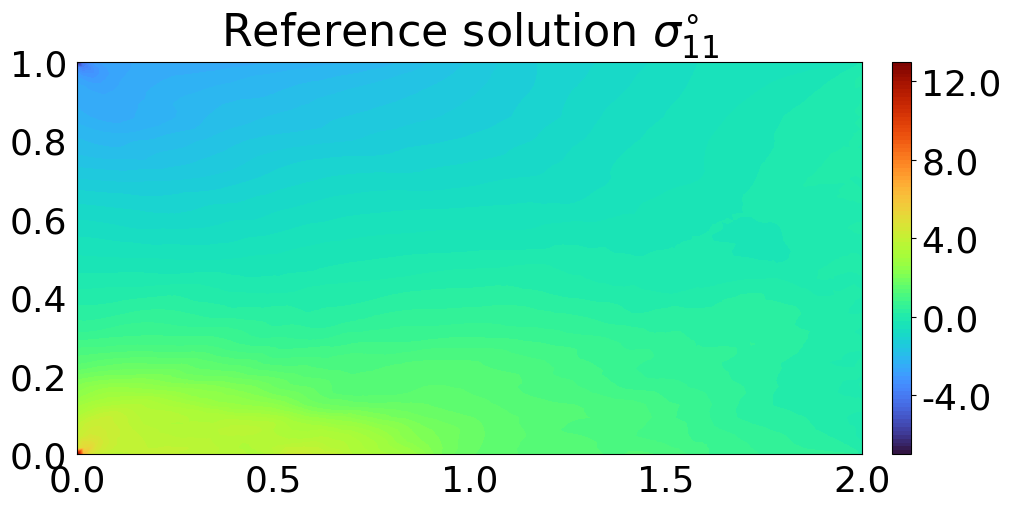

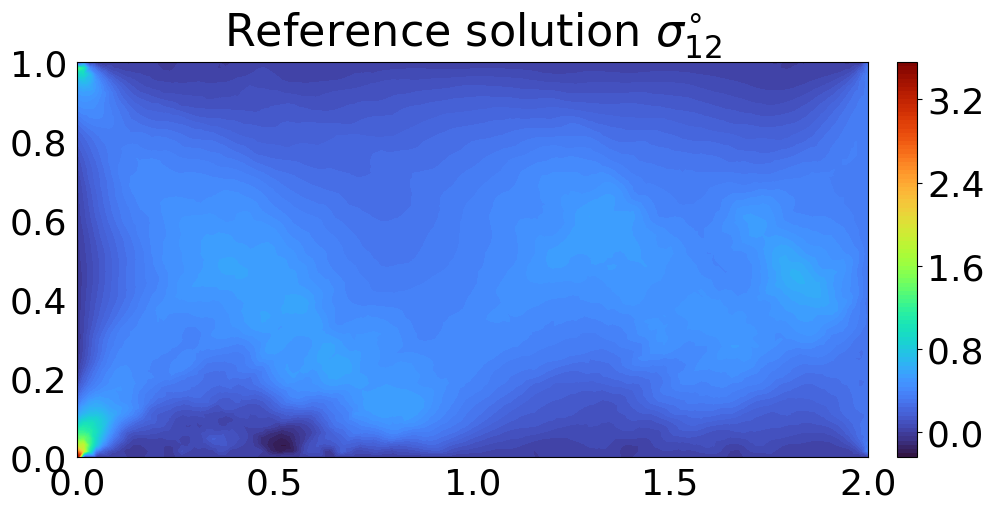

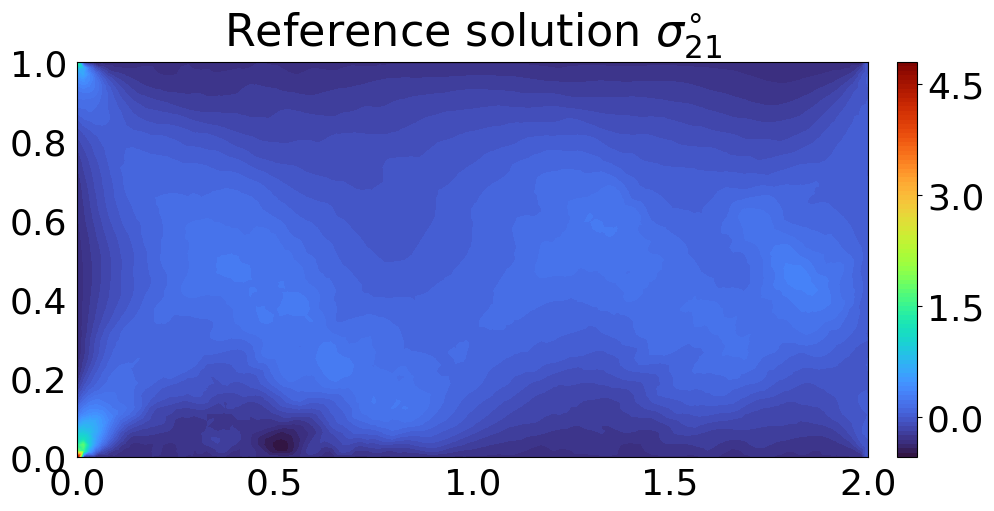

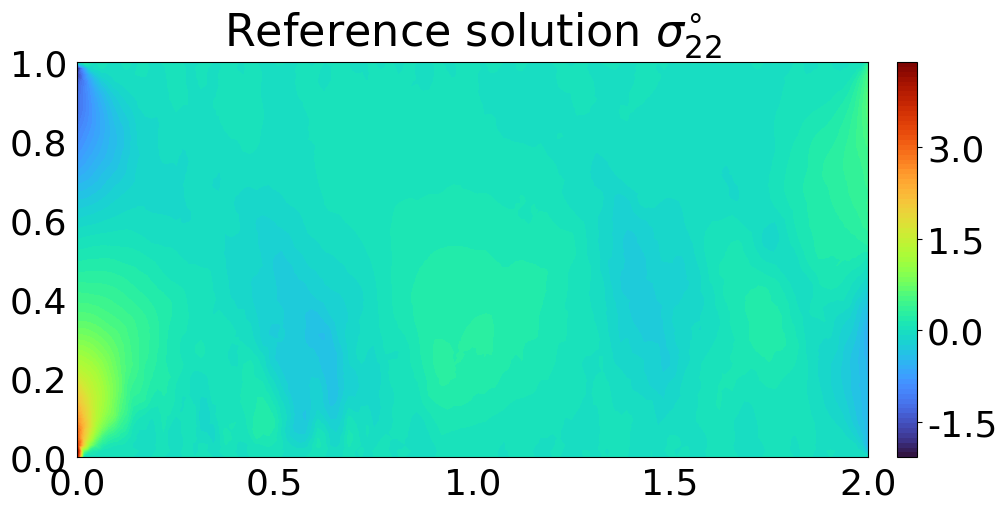

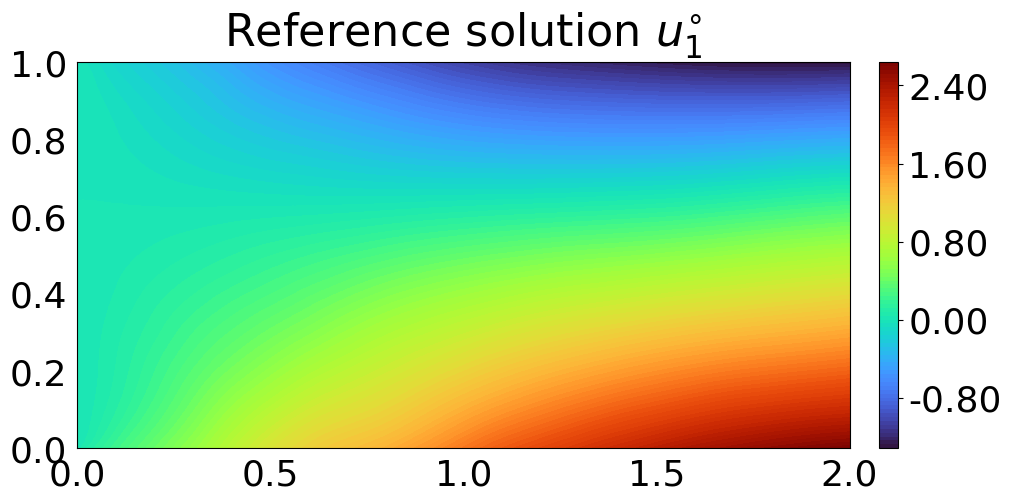

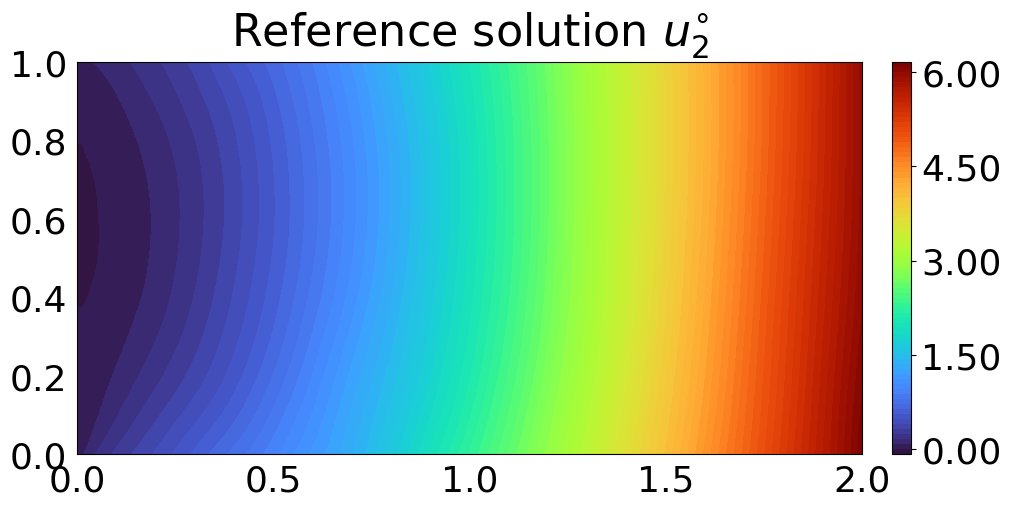

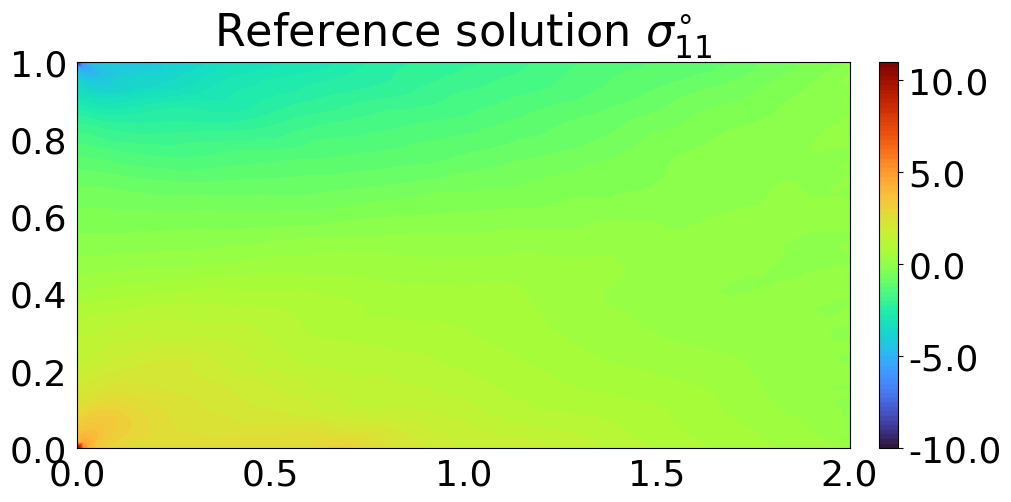

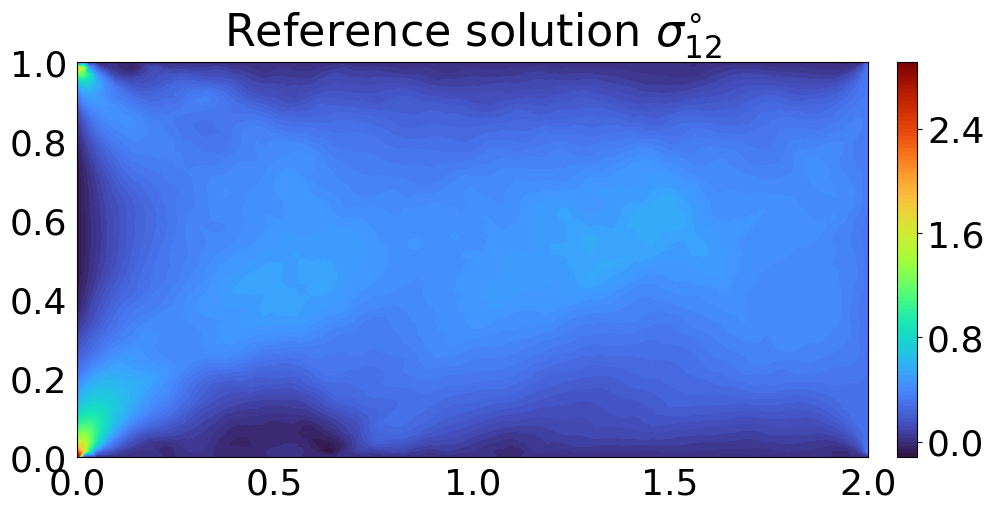

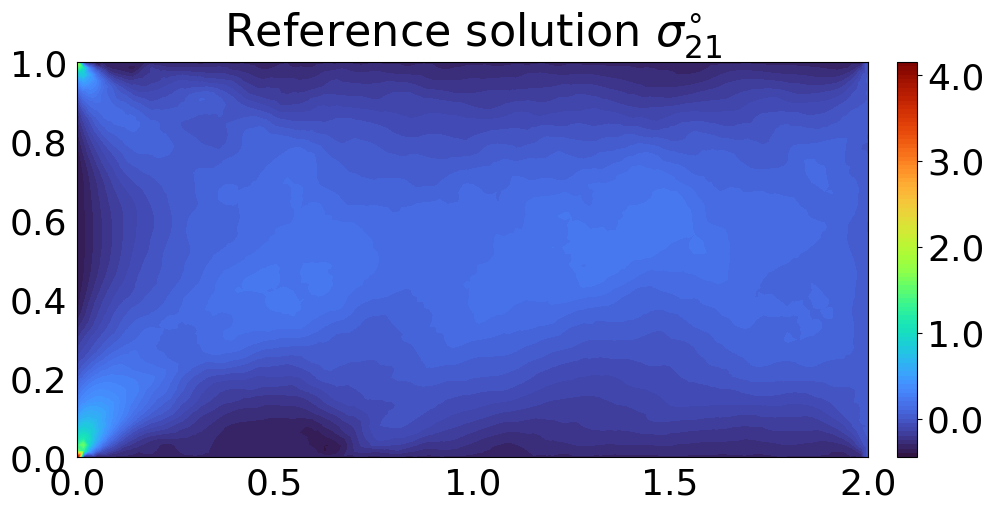

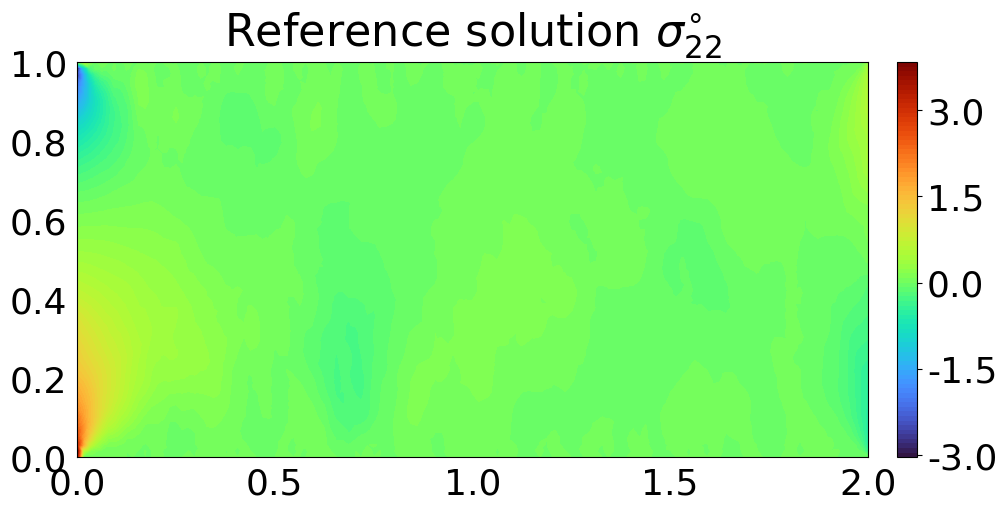

In [10]:
for test_sample_index in range(3):
    ref_sigma_u_fc = dolfinx.fem.Function(Vh['sigma_u'])
    ref_sigma_u_fc.x.array[:] = test_sigma_u_dof[test_sample_index]
    ref_sigma_fc = ref_sigma_u_fc.sub(0).collapse()
    ref_u_fc = ref_sigma_u_fc.sub(1).collapse()

    ref_sigma_grid_evals = evaluate_expression(mesh, ref_sigma_fc, mesh.geometry.x)[1]
    ref_u_grid_evals = evaluate_expression(mesh, ref_u_fc, mesh.geometry.x)[1]


    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]

    fig = plot_reference_scalar_function(x, y, ref_u_grid_evals[:, 0], variable_name=r'$u_1^{\circ}$', fmt="%.2f")
    fig.savefig(os.path.join(model_test_outputs_path, f'test_reference_u1_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

    fig = plot_reference_scalar_function(x, y, ref_u_grid_evals[:, 1], variable_name=r'$u_2^{\circ}$', fmt="%.2f")
    fig.savefig(os.path.join(model_test_outputs_path, f'test_reference_u2_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

    fig = plot_reference_scalar_function(x, y, ref_sigma_grid_evals[:, 0], variable_name=r'$\sigma_{11}^{\circ}$', fmt="%.1f")
    fig.savefig(os.path.join(model_test_outputs_path, f'test_reference_sigma11_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

    fig = plot_reference_scalar_function(x, y, ref_sigma_grid_evals[:, 1], variable_name=r'$\sigma_{12}^{\circ}$', fmt="%.1f")
    fig.savefig(os.path.join(model_test_outputs_path, f'test_reference_sigma12_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

    fig = plot_reference_scalar_function(x, y, ref_sigma_grid_evals[:, 2], variable_name=r'$\sigma_{21}^{\circ}$', fmt="%.1f")
    fig.savefig(os.path.join(model_test_outputs_path, f'test_reference_sigma21_{test_sample_index}.png'), dpi=300, bbox_inches='tight')

    fig = plot_reference_scalar_function(x, y, ref_sigma_grid_evals[:, 3], variable_name=r'$\sigma_{22}^{\circ}$', fmt="%.1f")
    fig.savefig(os.path.join(model_test_outputs_path, f'test_reference_sigma22_{test_sample_index}.png'), dpi=300, bbox_inches='tight')